In [17]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

In [2]:
df = pd.read_csv("/content/heart.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


Preuzmite dataset sa linka koji vam je dostupan u datoteci datasets_klasifikacija_binarni.txt. Taj dataset ste koristili u zadaći 03A, a i u zadaći 11. Iz dataseta izbacite sve značajke koje nisu numeričke, a ako negdje nedostaje vrijednost umetnite medijan. Izbacite i target varijablu. Nakon toga standardizirajte podatke koristeći RobustScaler, pa trenirajte k-means algoritam za klasteriranje. Na kraju provjerite ARI i AMI vrijednosti.

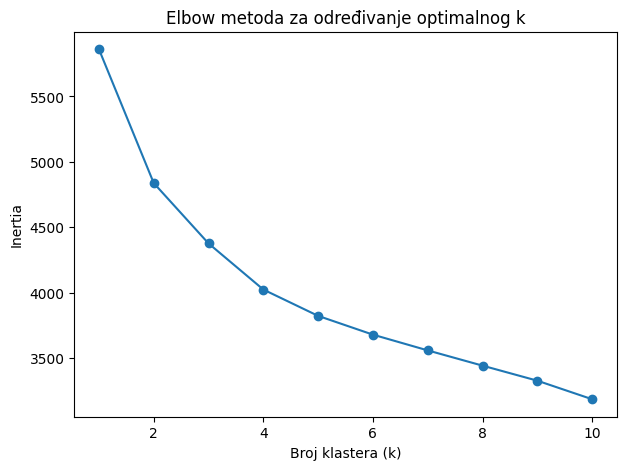

In [20]:
X = df.drop(columns=['target'])
y = df['target']

scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

inertia = []
K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(7, 5))
plt.plot(K, inertia, marker='o')
plt.xlabel('Broj klastera (k)')
plt.ylabel('Inertia')
plt.title('Elbow metoda za određivanje optimalnog k')
plt.show()


ARI: 0.1951
AMI: 0.1546


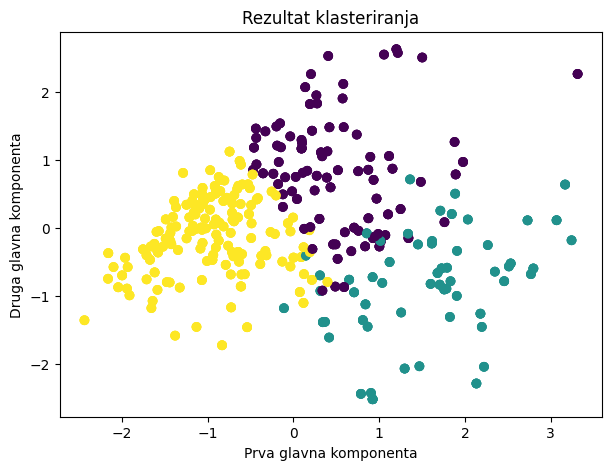

In [31]:
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
labels = kmeans.fit_predict(X_scaled)

ari = adjusted_rand_score(y, labels)
ami = adjusted_mutual_info_score(y, labels)

print(f"ARI: {ari:.4f}")
print(f"AMI: {ami:.4f}")

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(7, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis')
plt.xlabel('Prva glavna komponenta')
plt.ylabel('Druga glavna komponenta')
plt.title('Rezultat klasteriranja')
plt.show()
